# Endogeneity and instruments

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jean-jsj/CARD/blob/main/examples/02_endogeneity.ipynb)

The endogeneity-on cell and its control are generated from identical random draws; the toggle couples discount depth to a hidden demand shock. This notebook fits the naive and the instrumented reference estimators on both cells and shows the confounding appear — and the instrument remove it. Runtime: a few minutes.

In [1]:
import os, subprocess, sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("card_metrics").is_dir():
    subprocess.run(["git", "clone", "-q", "https://github.com/jean-jsj/CARD"], check=True)
    os.chdir("CARD")
elif Path.cwd().name == "examples":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd

In [2]:
from huggingface_hub import snapshot_download

CELLS = {"on": "complex_log_log_endogenous_seed001",
         "off": "complex_log_log_exogenous_seed001"}
for cell in CELLS.values():
    snapshot_download(repo_id="jean-jsj/CARD", repo_type="dataset",
                      allow_patterns=[f"dev_mini/{cell}/*"], local_dir="benchmark")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Fit both corners of the reference grid on both cells: a per-product Poisson demand model, identical except that the `iv` corner instruments price with `supply_cost_proxy`.

In [3]:
from card_metrics.baselines import loglog_grid

fits = {}
for knob, cell in CELLS.items():
    d = Path("benchmark/dev_mini") / cell / "public"
    train = pd.read_csv(d / "transactions_train_public.csv")
    products = pd.read_csv(d / "products_public.csv")
    for corner, use_iv in [("naive", False), ("iv", True)]:
        fits[knob, corner] = loglog_grid.fit_loglog_corner(train, products,
                                                           use_iv=use_iv, use_text=True)

{k: round(np.mean([c["beta"] for c in f["coefs"].values()]), 2) for k, f in fits.items()}

{('on', 'naive'): np.float64(-2.12),
 ('on', 'iv'): np.float64(-1.84),
 ('off', 'naive'): np.float64(-1.65),
 ('off', 'iv'): np.float64(-1.78)}

With the coupling on, the naive estimator sees discounts co-occur with the hidden demand surge and overstates the own-price elasticity (−2.1 vs the instrumented −1.8). In the control cell the two agree. Per product:

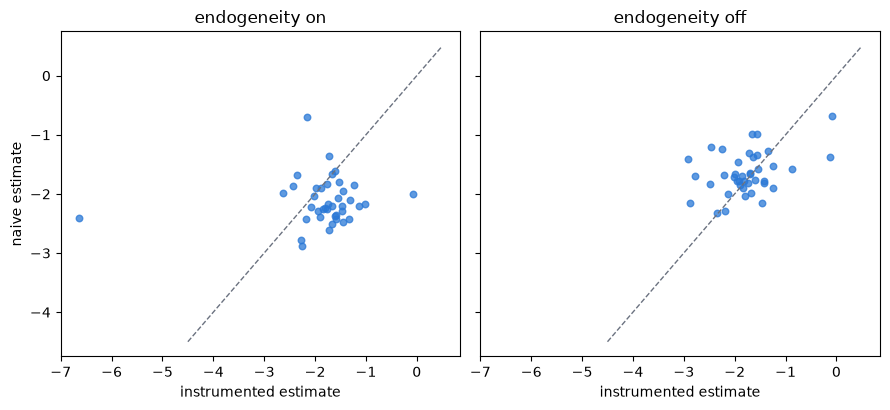

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharex=True, sharey=True)
for ax, knob in zip(axes, ["on", "off"]):
    naive, iv = fits[knob, "naive"]["coefs"], fits[knob, "iv"]["coefs"]
    ok = [p for p in naive if naive[p]["converged"] and iv[p]["converged"]]
    ax.plot([-4.5, 0.5], [-4.5, 0.5], ls="--", c="#6b7280", lw=1)
    ax.scatter([iv[p]["beta"] for p in ok], [naive[p]["beta"] for p in ok],
               s=22, c="#2a78d6", alpha=0.75)
    ax.set(title=f"endogeneity {knob}", xlabel="instrumented estimate")
axes[0].set_ylabel("naive estimate")
plt.tight_layout()

Now the scored consequence: predict the headline scenario (the flagship product's price +10%) with each fit, and score against the hidden truth in both cells.

In [5]:
import json

bias = {}
for (knob, corner), params in fits.items():
    cell_dir = Path("benchmark/dev_mini") / CELLS[knob]
    holdout = pd.read_csv(cell_dir / "public/transactions_holdout_context_public.csv")
    sweep = pd.read_csv(cell_dir / "public/counterfactual_sweep_context_public.csv")
    products = pd.read_csv(cell_dir / "public/products_public.csv")

    sub = Path("submissions_local") / corner / CELLS[knob]
    sub.mkdir(parents=True, exist_ok=True)
    loglog_grid.predict_holdout_units(params, holdout).to_csv(sub / "forecast_predictions.csv", index=False)
    loglog_grid.elasticity_matrix(params, products).to_csv(sub / "elasticity_matrix.csv", index=False)
    loglog_grid.predict_sweep_deltas(params, sweep, holdout).to_csv(sub / "counterfactual_deltas.csv", index=False)

    out = Path("submissions_local") / f"{corner}_{knob}.json"
    subprocess.run([sys.executable, "-m", "card_metrics.evaluate_submission",
                    "--cell-dir", str(cell_dir), "--submission-dir", str(sub),
                    "--submission-name", corner, "--out", str(out)],
                   check=True, capture_output=True)
    score = json.loads(out.read_text())
    bias[knob, corner] = score["counterfactual_prediction"]["headline"]["own_price"]["own_price_wmpe"]

bias

{('on', 'naive'): 0.08693330541258892,
 ('on', 'iv'): 0.09585297753405939,
 ('off', 'naive'): 0.42140999068849594,
 ('off', 'iv'): 0.1229443866114433}

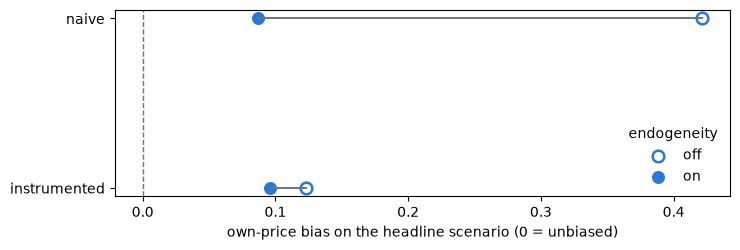

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 2.6))
for y, corner in enumerate(["iv", "naive"]):
    off, on = bias["off", corner], bias["on", corner]
    ax.plot([off, on], [y, y], c="#6b7280", lw=1.4)
    ax.scatter([off], [y], s=70, facecolors="white", edgecolors="#2a78d6", lw=1.8, label="off" if y == 0 else None)
    ax.scatter([on], [y], s=70, c="#2a78d6", label="on" if y == 0 else None)
ax.axvline(0, ls="--", c="#6b7280", lw=1)
ax.set(yticks=[0, 1], yticklabels=["instrumented", "naive"],
       xlabel="own-price bias on the headline scenario (0 = unbiased)")
ax.legend(title="endogeneity", frameon=False, loc="lower right")
plt.tight_layout()

Read the movement, not the levels: on a 10-store slice both corners carry a small-sample offset, but turning the knob on moves the naive corner by roughly −0.3 while the instrumented corner barely moves. On the full cells the offset disappears and the same movement lands naive at bias −0.23 with the instrumented corners on the zero line — the full reference grid is in [docs/reference_results.html](../docs/reference_results.html).